# Training a YOLO Pose Model for Custom Keypoint Tracking

Most pre-trained computer vision models are optimized for general datasets (for example, people, vehicles, or everyday objects) and do not directly model domain-specific keypoints such as those on a Kendo sword or a baseball bat.  
To track these reliably, we fine-tune a pre-trained model on a custom labeled dataset using **transfer learning**. This lets the model adapt existing visual features to your specific objects and keypoint definitions with far less data and compute than training from scratch.

### Step 0: Environment Setup

Before we begin, I recommend creating a new Python virtual environment and install the necessary Python libraries. Think of this as setting up your digital laboratory.

- To create a new Python virtual environment, go to your terminal, navigate to the folder where you want to save the environment (using cd your/chosen/path) and then type the following.

```python
python3.12 - venv CV_VEnv
```

- **Activate the environment.**

`source path/to/CV_VEnv/bin/activate # For Mac/Linux`

or

`venv\Scripts\activate # For Windows CMD`

- **Next, install `ipykernel`** using `pip install ipykernel` on the terminal.

- **Register the Jupyter kernel**

`path/to/CV_VEnv/bin/python -m ipykernel install --user --name CV_VEnv --display-name "CV_VEnv"`

- Open your notebook from this virtual environment using `jupyter notebook` and select "CV_VEnv" Kernel.

---

### Step 1: Extracting Training Data - Frames from videos

The first step is building a small "dataset" of images extracted from the videos and maually label them. About 100 to 200  images of the object in various positions, lighting, and states of motion blur should be sufficient to start training our model.

We will use OpenCV to automatically slice our training videos into a folder of still images. We have built two modes for this:
1. **Evenly Spaced (`method="evenly"`):** Grabs a frame every few seconds. Great for getting a chronological sample of the whole video.
2. **Random (`method="random"`):** Grabs frames at completely random times. This is the secret to a great AI, as it forces the model to learn what the object looks like in weird, unexpected, and chaotic situations!


For this notebook, we will be using:
* **`ultralytics`**: The engine for YOLO26, which handles object detection and tracking.
* **`opencv-python`**: The industry standard for video and image processing (reading frames, drawing skeletons, and saving videos).
* **`pandas` & `numpy`**: The "bread and butter" of data science for handling our coordinate spreadsheets and math.
* **`scipy`**: Used for the advanced "Hungarian Algorithm" math that helps us identify people across frames.
* **`matplotlib`**: Our graphing library for visualizing strike velocities.
* **`tqdm`**: A utility to give us those beautiful progress bars so we aren't left guessing if the code is still running.

*Note: In a Jupyter environment, we use the `!` prefix to run terminal commands directly from a cell.*

In [ ]:
# Install the necessary packages for AI, Computer Vision, and Data Science
print("📦 Installing laboratory equipment (this may take a minute)...")
!pip install ultralytics opencv-python pandas numpy scipy matplotlib tqdm | tail -1

### Step 2: Automated Multi-Video Frame Extraction

To make our pipeline scalable, we are automating the folder management. Instead of manually creating directories, this script will:
1. **Identify each video** in your input folder.
2. **Create a unique sub-folder** for each video using the name of the video file followed by the suffix `extracted-frames_`.
3. **Organize the frames** directly into their respective folders.

This approach ensures that if you have 10 videos, all the images stay grouped logically, making it much easier to manage your training data.

We will continue to use the **Random** sampling method by default, as it provides the best data variety, generally preferred for training AI models.

In [3]:
import cv2
import os
import random
import glob
from tqdm import tqdm

In [6]:
def automate_frame_extraction(input_folder, frames_per_video=20, method="random"):
    """
    Automated extraction: Creates a unique folder for each video file
    within the same directory as the video.
    """
    print(f"Scanning for videos in: {input_folder}")
    
    if not os.path.exists(input_folder):
        print(f"ERROR: The directory '{input_folder}' does not exist.")
        return

    # Find video files (Case-Insensitive)
    video_files = []
    extensions = ('*.mp4', '*.MP4', '*.mov', '*.MOV', '*.avi', '*.AVI')
    for ext in extensions:
        video_files.extend(glob.glob(os.path.join(input_folder, ext)))

    if not video_files:
        print(f"No videos found! Files in directory: {os.listdir(input_folder)}")
        return

    print(f"Found {len(video_files)} video(s). Starting automated pipeline...")

    # Process each video independently
    for v_path in video_files:
        # Get directory and filename info
        v_dir = os.path.dirname(v_path)
        v_name = os.path.splitext(os.path.basename(v_path))[0]
        
        # Define the specific output folder for THIS video
        # Example: "MyStrike_extracted-frames_"
        output_subfolder = os.path.join(v_dir, v_name + "extracted-frames_")
        
        if not os.path.exists(output_subfolder):
            os.makedirs(output_subfolder)
        
        # Open video and get properties
        cap = cv2.VideoCapture(v_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames <= 0:
            print(f"Skipping {v_name} (Unable to read frame count).")
            cap.release()
            continue

        # Decide which frames to extract
        num_to_draw = min(frames_per_video, total_frames)
        if method == "evenly":
            indices = [int(i * (total_frames / num_to_draw)) for i in range(num_to_draw)]
        else: # random
            indices = random.sample(range(total_frames), num_to_draw)
            indices.sort()

        # Extract frames into the new sub-folder
        for idx in tqdm(indices, desc=f"Processing: {v_name}", leave=True):
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            success, frame = cap.read()
            if success:
                img_path = os.path.join(output_subfolder, f"{v_name}_f{idx:06d}.jpg")
                cv2.imwrite(img_path, frame)
        
        cap.release()
        print(f"Saved {num_to_draw} frames to: {os.path.basename(output_subfolder)}")

    print("\nPipeline complete! All videos have been processed into their respective folders.")

#### EXECUTE THE FRAME-EXTRACTION PIPELINE
Provide the path that contains the video(s) to the variable `target_path`. Generally, a total of 100-200 farmes would be a good start. So, if you have 5 videos, `frames_per_video` could be between 20 to 40.

In [ ]:
target_path = "/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/zuron/input_test" # Change this to your folder with videos

automate_frame_extraction(
    input_folder=target_path, 
    frames_per_video=2, 
    method="random"
)

### Step 3: Launching Label Studio (Locally)

Now that we have the extracted frames, we need to annotate the position of our intended objiects. We will use these annonated labels to train our custom model. We will use [Label Studio](https://labelstud.io/) for this.

**Step 3.1.**: Let's first install it on our working virtual environment. For more information on instllation, visit Label Studio's official [installation guide](https://labelstud.io/guide/install.html).

In [ ]:
!pip install label-studio | tail -1

Because Label Studio runs as a web server, launching it directly inside a notebook cell can block or destabilize the kernel. Instead, we launch it from the terminal (or as a background process) so the notebook remains responsive. This workflow will:
1. Launch the server in the background.
2. Wait for some time (could be a minute or two) for it to boot up.
3. Automatically open a new tab in your web browser so you can start labeling.

**Step 3.2.** Before launching Label Studio as a local server process, terminate any existing Label Studio or related background process to avoid port conflicts and ensure a clean startup.

In [18]:
if 'ls_process' in locals():
    ls_process.terminate()
    print("🛑 Cleaned up background processes.")

🛑 Cleaned up background processes.


#### Step 3.3.: Annotating the Dataset with Label Studio

Now that we have terminated any background processes, we will launch Label Studio directly from your Mac's Terminal to ensure it runs stably and allows us to monitor the server logs.

**Instructions:**

1. **Launch the Server:** Go to your Mac Terminal or Windows Command Prompt, type `label-studio`, and press return. This will start the server and automatically open a browser window to `http://localhost:8080`.
1. **Create an Account:** In the Label Studio web interface, first create an account with random email id and password (nothing is happening over the web, EVERYTHING is on your local machine). 
1. **Create the Project:** Once you are logged in, click the **"Create"** button in the top right. Give an appropriate name to your project like `Object_Kinematics`. Do NOT save it yet.
1. **Import Your Images:** Go to the **"Data Import"** tab. You can click on the "upload Files" or "Drag & Drop" the extracted image frames (generated in Step 1) into the browser. Keep the imported images under 100.
1. **Configure the Custom Keypoint Interface:** * Nest, go to the **"Labeling Setup"** tab and choose "Keypoint Labeling". Under the heading Add Label names", add appropriate names for each keypoints you want to annotate, like `object1_tip`, `object1_base`, `object2_tip`, `object2_base`, etc. Click on "add" after typing each label. Delete the in-built labels like "Face", "Nose" by hovering over the names and click on the delete icon. 
1. Click "Save".
1. **Annotate the Frames (The Workflow):** Click your first image to begin. 
   * **Label Keypoint** Click on the name of the keypoint on the top ribbon, and then click on the appropriate place on the image. repeat that for all the keypoints. Once you are done lableing all keypoints on a frame, click the "Submit" button in the bottom. Then click on the next image and repeat.
   * **If a Keypoint is hidden (Occluded):** If a keypoint is not visible,  **do not** drop the keypoint. Only label what is visible to your eye.
   * **If the object is missing:** If the object is not in the frame at all, do not draw any points. Click "Submit" on the empty frame to "teach" the model what "No object" looks like.

1. **Export the Raw Data:** Once all frames are labeled, return to the project dashboard by clicking on the name of the project on the top ribbon. Click the  **"Export"** button. Because standard YOLO Pose isn't directly available, select the standard **JSON** format (not JSON-MIN). 
1. **Save the File:** Download the exported file, rename it to `labels.json`, and place it in the same directory as this Jupyter Notebook.

*(Note: When you are completely finished with this phase, you can go back to your Mac Terminal and press `Ctrl + C` to safely shut down the Label Studio server.)*

#### Step 3.4 Parsing the Dataset & Auto-Generating Bounding Boxes

Because we only labeled the precise keypoints and skipped drawing bounding boxes, we need to adapt our data for YOLO. 

YOLO Pose strictly requires a bounding box for every object. This script will:
1. Parse the `labels.json` file to find `object1_tip`, `object1_base`, `object2_tip`, and `object2_base`.

2. Mathematically calculate a bounding box that perfectly surrounds the keypoints for each object, adding a 5% "padding" so the edges of the objects aren't cut off.
3. Output the properly formatted `.txt` files into our `CustomObject_Dataset/labels` folder.

In [9]:
import json
import os
import shutil

def generate_bbox(kp_tip, kp_base, padding=0.05):
    """Calculates a bounding box around 2 keypoints with a slight padding."""
    pts_x = [p[0] for p in [kp_tip, kp_base] if p[2] == 2]
    pts_y = [p[1] for p in [kp_tip, kp_base] if p[2] == 2]
    
    if not pts_x: return None # No visible points
    
    min_x, max_x = min(pts_x), max(pts_x)
    min_y, max_y = min(pts_y), max(pts_y)
    
    if len(pts_x) == 1:
        w, h = padding * 2, padding * 2
    else:
        w = (max_x - min_x) + (padding * 2)
        h = (max_y - min_y) + (padding * 2)
        
    cx = (min_x + max_x) / 2.0
    cy = (min_y + max_y) / 2.0
    
    return [max(0, min(1, cx)), max(0, min(1, cy)), max(0, min(1, w)), max(0, min(1, h))]

def prepare_custom_yolo_dataset(json_path, source_images_dir, output_dir="CustomObject_Dataset"):
    print("🔄 Starting Data Translation & Box Generation...")
    
    images_dir, labels_dir = os.path.join(output_dir, 'images'), os.path.join(output_dir, 'labels')
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    with open(json_path, 'r') as f: data = json.load(f)

    processed_count = 0

    for task in data:
        raw_image_path = task['data']['img'] if 'img' in task['data'] else task['data']['image']
        basename = os.path.basename(raw_image_path)
        
        # FIX: We only split on the FIRST hyphen. 
        # So "607354f7-Ignis_Training1-1_Strikes.jpg" becomes "Ignis_Training1-1_Strikes.jpg"
        if '-' in basename:
            image_filename = basename.split('-', 1)[1]
        else:
            image_filename = basename
        
        src_image_path, dst_image_path = os.path.join(source_images_dir, image_filename), os.path.join(images_dir, image_filename)
        
        if not task.get('annotations') or not task['annotations'][0].get('result'):
            continue
            
        results = task['annotations'][0]['result']
        
        object1_tip, object1_base = [0.0, 0.0, 0], [0.0, 0.0, 0]
        object2_tip, object2_base = [0.0, 0.0, 0], [0.0, 0.0, 0]
        
        for item in results:
            if item['type'] == 'keypointlabels':
                val = item['value']
                kx, ky = val['x'] / 100.0, val['y'] / 100.0
                label = val['keypointlabels'][0]
                
                if label == 'object1_tip': object1_tip = [kx, ky, 2]
                elif label == 'object1_base': object1_base = [kx, ky, 2]
                elif label == 'object2_tip': object2_tip = [kx, ky, 2]
                elif label == 'object2_base': object2_base = [kx, ky, 2]

        yolo_lines = []
        
        # Process Object 1 (Class 0)
        object1_box = generate_bbox(object1_tip, object1_base)
        if object1_box:
            yolo_lines.append(f"0 {object1_box[0]:.6f} {object1_box[1]:.6f} {object1_box[2]:.6f} {object1_box[3]:.6f} {object1_tip[0]:.6f} {object1_tip[1]:.6f} {object1_tip[2]} {object1_base[0]:.6f} {object1_base[1]:.6f} {object1_base[2]}\n")
            
        # Process Object 2 (Class 1)
        object2_box = generate_bbox(object2_tip, object2_base)
        if object2_box:
            yolo_lines.append(f"1 {object2_box[0]:.6f} {object2_box[1]:.6f} {object2_box[2]:.6f} {object2_box[3]:.6f} {object2_tip[0]:.6f} {object2_tip[1]:.6f} {object2_tip[2]} {object2_base[0]:.6f} {object2_base[1]:.6f} {object2_base[2]}\n")

        if yolo_lines:
            txt_filepath = os.path.join(labels_dir, os.path.splitext(image_filename)[0] + '.txt')
            with open(txt_filepath, 'w') as f:
                f.writelines(yolo_lines)
                
            if os.path.exists(src_image_path):
                shutil.copy(src_image_path, dst_image_path)
                processed_count += 1
            else:
                print(f"⚠️ Image missing: {src_image_path}")

    print(f"✅ Conversion Complete! Processed {processed_count} frames into '{output_dir}'.")

In [10]:
# ==========================================
# EXECUTE THE CONVERSION
# ==========================================
# UPDATE THIS PATH to where your extracted frames are!
SOURCE_IMAGES = "/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/zuron/input_test/Ignis_Training1-1_Strikes_Uncutextracted-frames_" 

prepare_custom_yolo_dataset("labels.json", SOURCE_IMAGES)

🔄 Starting Data Translation & Box Generation...
✅ Conversion Complete! Processed 16 frames into 'CustomObject_Dataset'.


#### Step 3.4. Generating the Configuration File (`data.yaml`)

We now generate the configuration file for YOLO. 
Because we labeled attacking and defending objects separately, we are telling the model to look for **2 Classes**, each with **2 Keypoints**.

In [11]:
import os
import yaml

# Get absolute path to ensure YOLO finds the dataset
dataset_folder = "CustomObject_Dataset"
abs_path = os.path.abspath(dataset_folder)

yaml_data = {
    'path': abs_path,
    'train': 'images', 
    'val': 'images',   
    'names': {
        0: 'Object_1',
        1: 'Object_2'
    },
    'kpt_shape': [2, 3] # 2 keypoints (Tip, Base), 3 values each (x, y, visibility)
}

yaml_file_path = os.path.join(dataset_folder, 'data.yaml')

with open(yaml_file_path, 'w') as f:
    yaml.dump(yaml_data, f, sort_keys=False)

print(f"✅ Configuration saved to: {yaml_file_path}")

✅ Configuration saved to: CustomObject_Dataset/data.yaml


#### Step 3.5. Training the Dual-Object Pose Model

The data is fully parsed and mapped! We will now initialize the YOLOv26 Nano Pose model and fine-tune it on our dataset. The model will learn to distinguish not only the tip from the base, but object 1 from object 2.

In [ ]:
from torch._C import device
from ultralytics import YOLO
import os

# ==========================================
# CHANGE THESE SETTINGS BEFORE TRAINING
# ==========================================

num_epochs = 5 # Change this to 50 for a full training run, but we'll use 5 for testing purposes
device = 'mps' # Change to 'gpu' if you have a compatible GPU, 'mps' if on a Mac Apple Silicon chip, or 'cpu' if you have just CPU support.

print("Initializing YOLO Pose Model...")

# Load the pre-trained nano pose model
model = YOLO('yolo26n-pose.pt') 

dataset_yaml_path = os.path.abspath("CustomObject_Dataset/data.yaml")

print(f"Starting training... This will process {num_epochs} epochs.")

# Train the model
results = model.train(
    data=dataset_yaml_path,
    epochs=num_epochs,                  
    imgsz=640,                  
    project='Object_Tracker_Runs', 
    name='custom_object_model',    
    device=device
)

print("✅ Training Complete!")
print("The custom YOLO Model is saved in: Object_Tracker_Runs/custom_object_model/weights/best.pt")

### Step 5.5: Evaluating Model Health & Efficiency

Before we run our model on a new video, we need to check its "report card." During training, YOLO automatically tracked several key metrics:

1. **Loss (Box & Pose):** This measures how "wrong" the AI's predictions were compared to our Label Studio annotations. **We want this number to go DOWN** over the 50 epochs.
2. **mAP (Mean Average Precision):** This is the AI's accuracy score. `mAP50(P)` specifically measures how accurately it found our Tip and Base keypoints (Pose). **We want this number to go UP** (closer to 1.0 or 100%).

Let's visualize the training results!

Loading Training Metrics...

Here is the complete training overview generated by YOLO:


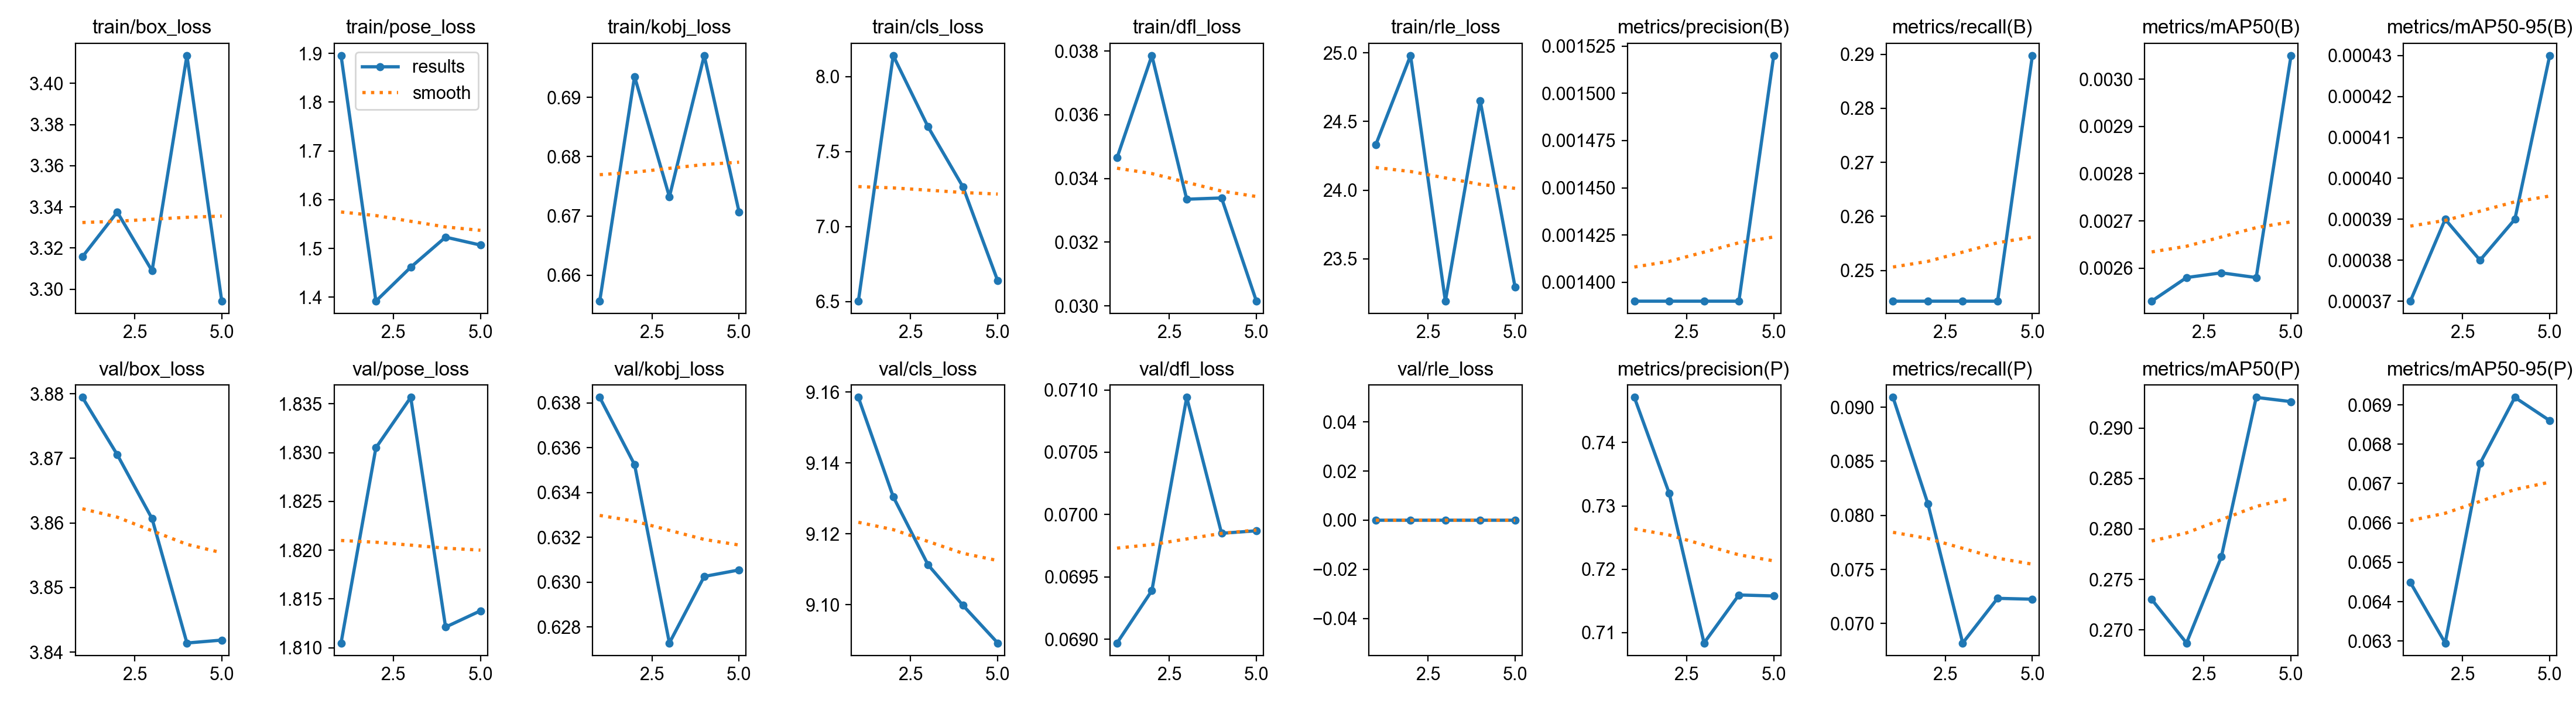

<Figure size 1200x500 with 2 Axes>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import os

print("Loading Training Metrics...\n")

run_dir = 'runs/pose/Object_Tracker_Runs/custom_object_model'

# ---------------------------------------------------------
# OPTION 1: View YOLO's Auto-Generated Summary Grid
# ---------------------------------------------------------
results_img_path = os.path.join(run_dir, 'results.png')
if os.path.exists(results_img_path):
    print("Here is the complete training overview generated by YOLO:")
    display(Image(filename=results_img_path, width=800))
else:
    print("Could not find YOLO's auto-generated results.png")

# ---------------------------------------------------------
# OPTION 2: Plot the raw CSV data ourselves using Pandas!
# ---------------------------------------------------------
csv_path = os.path.join(run_dir, 'results.csv')

if os.path.exists(csv_path):
    # Read the data
    df = pd.read_csv(csv_path)
    # YOLO adds weird spaces to column names, so we strip them
    df.columns = df.columns.str.strip() 
    
    # Create a custom plot
    plt.figure(figsize=(12, 5))
    
    # Plot 1: The Loss Curve (Should go down)
    plt.subplot(1, 2, 1)
    if 'train/pose_loss' in df.columns:
        plt.plot(df['epoch'], df['train/pose_loss'], label='Training Pose Loss', color='red', linewidth=2)
        plt.plot(df['epoch'], df['val/pose_loss'], label='Validation Pose Loss', color='orange', linewidth=2)
    plt.title('Keypoint (Pose) Error Over Time\n(Lower is Better)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: The Accuracy Curve (Should go up)
    plt.subplot(1, 2, 2)
    if 'metrics/mAP50(P)' in df.columns:
        plt.plot(df['epoch'], df['metrics/mAP50(P)'], label='Pose Accuracy (mAP@50)', color='green', linewidth=2)
    plt.title('Keypoint Detection Accuracy\n(Higher is Better)')
    plt.xlabel('Epoch')
    plt.ylabel('mAP (0 to 1.0)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Could not find results.csv")

**What to look for when you run this:**
- The Loss Curve (Left Graph): You want to see a steep drop in the first 10-20 epochs, followed by a gradual leveling off (a nice "L" shape). If the Validation Loss starts spiking back up at the end, it means the model is "overfitting" (memorizing the data instead of learning the concept).

- The mAP Curve (Right Graph): You want to see this climb up toward 0.8 or 0.9 (80% to 90% accuracy). If the objects blur heavily during a fast swing, anything above 0.7 for a custom pose model on a small dataset is actually a massive victory!

### Step 6: Extracting Kinematic Data from a New Video

Once our model is fully trained, we will use it to analyze a completely new video. 

This script will feed the video into our custom YOLO model frame-by-frame. The model will locate the Object 1 and the Object 2, and extract the precise X and Y coordinates for the Tip and Base of each. 

Instead of just drawing lines on a video, we are going to export this raw data into a **CSV spreadsheet**. This is the foundation of sports analytics—with this CSV, we can calculate swing speed, impact angles, and acceleration!

* **Dynamic Naming:** The pipeline automatically names the output `.csv` file based on the file name of the input video so you never accidentally overwrite your data!

* If the model is "young" (trained on limited data), it might have lower confidence. We have lowered the confidence threshold (`conf=0.1`) so the model doesn't aggressively filter out its predictions. With more training, you can eventually push it to even 0.9.

In [ ]:
from ultralytics import YOLO
import pandas as pd
import numpy as np
import cv2
import os
from tqdm import tqdm

def extract_object_kinematics(video_path, model_path):
    # 1. Dynamically generate the output CSV filename
    base_name = os.path.basename(video_path)                  # e.g., "my_video.mp4"
    file_name_without_ext = os.path.splitext(base_name)[0]    # e.g., "my_video"
    output_csv = f"{file_name_without_ext}_custom_model_objectTracking_data.csv"
    
    print(f"Loading custom model from: {model_path}")
    model = YOLO(model_path)
    
    # 2. Get the total frame count for our progress bar
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    
    print(f"Processing video ({total_frames} frames): {video_path}")
    
    # verbose=False STOPS YOLO from printing every single frame to the screen
    results = model.predict(source=video_path, stream=True, conf=0.1, verbose=False)
    
    kinematics_data = []
    
    # 3. Extract the math frame-by-frame
    for frame_idx, result in enumerate(tqdm(results, total=total_frames, desc="📊 Extracting Data")):
        
        row = {
            'frame': frame_idx,
            'object1_tip_x': np.nan, 'object1_tip_y': np.nan,
            'object1_base_x': np.nan, 'object1_base_y': np.nan,
            'object2_tip_x': np.nan, 'object2_tip_y': np.nan,
            'object2_base_x': np.nan, 'object2_base_y': np.nan
        }
        
        if result.boxes is not None and result.keypoints is not None:
            class_ids = result.boxes.cls.cpu().numpy() # 0 = Attacking, 1 = Defending
            kpts = result.keypoints.xy.cpu().numpy()   # The X, Y coordinates
            
            for i, cls_id in enumerate(class_ids):
                if len(kpts[i]) >= 2:
                    tip = kpts[i][0]
                    base = kpts[i][1]
                    
                    if cls_id == 0: # Object 1
                        if tip[0] != 0 or tip[1] != 0:
                            row['object1_tip_x'], row['object1_tip_y'] = tip[0], tip[1]
                        if base[0] != 0 or base[1] != 0:
                            row['object1_base_x'], row['object1_base_y'] = base[0], base[1]
                            
                    elif cls_id == 1: # Object 2
                        if tip[0] != 0 or tip[1] != 0:
                            row['object2_tip_x'], row['object2_tip_y'] = tip[0], tip[1]
                        if base[0] != 0 or base[1] != 0:
                            row['object2_base_x'], row['object2_base_y'] = base[0], base[1]
        
        kinematics_data.append(row)
        
    # 4. Save to the dynamically named CSV
    df = pd.DataFrame(kinematics_data)
    df.to_csv(output_csv, index=False)
    
    print(f"\n✅ Extraction complete!")
    print(f"Saved {len(df)} frames of coordinate data to: '{output_csv}'")
    
    return df

In [ ]:
# ==========================================
# EXECUTE THE EXTRACTION
# ==========================================
# 1. Provide the path to a completely new video of a strike
TEST_VIDEO = "/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/zuron/input_test/Ignis_Training1-1_Strikes_Uncut.MP4"

# 2. Point to the model we just finished training!
TRAINED_MODEL = "runs/pose/Object_Tracker_Runs/custom_object_model/weights/best.pt"

df_kinematics = extract_object_kinematics(TEST_VIDEO, TRAINED_MODEL)

print("\nSneak peek at your new Kinematics Dataset:")
print(df_kinematics.head())

### Step 7: Drawing the Tracking Overlay

Now that we have successfully extracted our coordinate data into a `.csv` file, we can visualize it! 

This script takes our raw dataset and overlays it back onto the original video. We will use OpenCV to draw physical lines connecting the Base and Tip of each object frame-by-frame. 

* **Object 1:** Drawn with a Red line.
* **Object 2:** Drawn with a Blue line.
* **Tips:** Marked with a bright Yellow dot so we can easily track the striking edge.

In [ ]:
import cv2
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

def overlay_tracking_data(video_path, csv_path):
    # Dynamically name the output video
    base_name = os.path.basename(video_path)
    file_name_without_ext = os.path.splitext(base_name)[0]
    output_video = f"{file_name_without_ext}_tracking_overlay.mp4"
    
    print(f"Loading coordinate data from: {csv_path}")
    df = pd.read_csv(csv_path)
    
    print(f"Opening original video: {video_path}")
    cap = cv2.VideoCapture(video_path)
    
    # Grab video properties to configure the output writer
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Setup the video writer (mp4 format)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))
    
    for frame_idx in tqdm(range(total_frames), desc="Drawing Skeletons"):
        ret, frame = cap.read()
        if not ret:
            break  # End of video
            
        # Check if we have data for this frame in our CSV
        if frame_idx < len(df):
            row = df.iloc[frame_idx]
            
            # Draw Object 1 (Red Line)
            # We check if the data is NOT a NaN value
            if not pd.isna(row['object1_tip_x']) and not pd.isna(row['object1_base_x']):
                tip = (int(row['object1_tip_x']), int(row['object1_tip_y']))
                base = (int(row['object1_base_x']), int(row['object1_base_y']))
                
                # cv2.line(image, start_point, end_point, color(B,G,R), thickness)
                cv2.line(frame, tip, base, (0, 0, 255), 4)       # Red Line
                cv2.circle(frame, base, 6, (0, 0, 255), -1)      # Red Base Dot
                cv2.circle(frame, tip, 6, (0, 255, 255), -1)     # Yellow Tip Dot
                
            # Draw Object 2 (Blue Line)
            if not pd.isna(row['object2_tip_x']) and not pd.isna(row['object2_base_x']):
                tip = (int(row['object2_tip_x']), int(row['object2_tip_y']))
                base = (int(row['object2_base_x']), int(row['object2_base_y']))
                
                cv2.line(frame, tip, base, (255, 0, 0), 4)       # Blue Line
                cv2.circle(frame, base, 6, (255, 0, 0), -1)      # Blue Base Dot
                cv2.circle(frame, tip, 6, (0, 255, 255), -1)     # Yellow Tip Dot

        # Write the modified frame to our new video
        out.write(frame)
        
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    
    print(f"\nVideo render complete!")
    print(f"Saved annotated video to: '{output_video}'")

# ==========================================
# EXECUTE THE RENDER
# ==========================================
# 1. Provide the path to your original video
TEST_VIDEO = "/Users/souvikmandal/Documents/S06_Teaching_Mentoring_Talks/LS100/2026_Sem01/media/zuron/input_test/Ignis_Training1-1_Strikes_Uncut.mp4"

# 2. Provide the path to the CSV we just generated
CSV_DATA = "Ignis_Training1-1_Strikes_Uncut_custom_model_objectTracking_data.csv"

overlay_tracking_data(TEST_VIDEO, CSV_DATA)